# Step 1

In [ ]:
#import important library
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os
import cv2
import torch
import torchvision
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms, models
from PIL import Image
from torchvision.datasets import ImageFolder
from torch.utils.data.dataset import ConcatDataset
from torchvision import models

In [ ]:
#connecting to drive for data file
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
#dataset
# Spiral dataset
Train_healthy_spiral = "/content/drive/MyDrive/All_image/image_data/spiral/training/healthy"
Train_Pak_spiral = "/content/drive/MyDrive/All_image/image_data/spiral/training/parkinson"
Test_healthy_spiral = "/content/drive/MyDrive/All_image/image_data/spiral/testing/healthy"
Test_Pak_spiral = "/content/drive/MyDrive/All_image/image_data/spiral/testing/parkinson"

# Wave dataset
Train_healthy_wave = "/content/drive/MyDrive/All_image/image_data/wave/training/healthy"
Train_Pak_wave = "/content/drive/MyDrive/All_image/image_data/wave/training/parkinson"
Test_healthy_wave = "/content/drive/MyDrive/All_image/image_data/wave/testing/healthy"
Test_Pak_wave = "/content/drive/MyDrive/All_image/image_data/wave/testing/parkinson"
###

print(
    f"No. of training healthy spiral images: {len(os.listdir(Train_healthy_spiral))}\n"
    f"No. of training parkinson spiral images: {len(os.listdir(Train_Pak_spiral))}\n"
    f"No. of testing healthy spiral images: {len(os.listdir(Test_healthy_spiral))}\n"
    f"No. of testing parkison spiral images: {len(os.listdir(Test_Pak_spiral))}\n"
    ######
    f"No. of training healthy wave images: {len(os.listdir(Train_healthy_wave))}\n"
    f"No. of training parkinson wave images: {len(os.listdir(Train_Pak_wave))}\n"
    f"No. of testing healthy wave images: {len(os.listdir(Test_healthy_wave))}\n"
    f"No. of testing parkison wave images: {len(os.listdir(Test_Pak_wave))}\n"
)

No. of training healthy spiral images: 36
No. of training parkinson spiral images: 36
No. of testing healthy spiral images: 15
No. of testing parkison spiral images: 15
No. of training healthy wave images: 36
No. of training parkinson wave images: 36
No. of testing healthy wave images: 15
No. of testing parkison wave images: 15



- major challeng here is data shortage, we have overall 144 images which quit small, but luckily we have a balance dataset
- my further approach will be data Augmentation

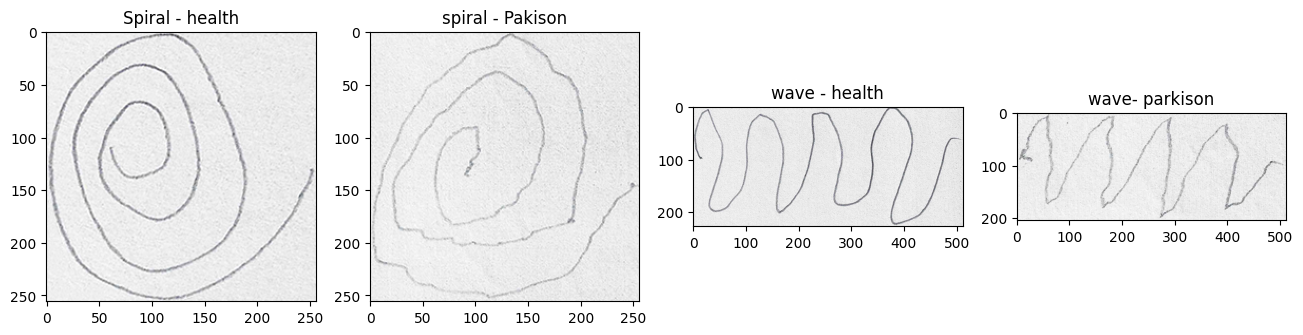

In [ ]:
#few image inspection , one sample from each group
paths = [
    ("Spiral - health", Train_healthy_spiral),
    ("spiral - Pakison", Train_Pak_spiral),
    ("wave - health", Train_healthy_wave),
    ("wave- parkison", Train_Pak_wave)
]

plt.figure(figsize = (16,4))

for i , (title, path) in enumerate(paths, 1):
  img_file = os.listdir(path)[4]
  img = Image.open(os.path.join(path, img_file))
  plt.subplot(1,4,i)
  plt.title(title)
  plt.imshow(img)



#STEP 2

In [ ]:
###Training Transform + Training Data augmentation
train_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels= 3),
    transforms.Resize((224,224)),
    transforms.RandomRotation(10),
    transforms.RandomAffine(degrees= 0, translate = (0.05, 0.05)),
    transforms.RandomPerspective(distortion_scale=0.2,p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(
        mean = [0.485, 0.456, 0.406],
        std = [0.229,0.224,0.225]
    )
])

In [ ]:
####Test Transform
test_transform = transforms.Compose ([
    transforms.Grayscale(num_output_channels= 3),
    transforms.Resize ((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean = [0.485, 0.456, 0.406],
        std = [0.229,0.224,0.225]
    )
])

In [ ]:
#####Dataset Loading
spiral_train = ImageFolder(root = "/content/drive/MyDrive/All_image/image_data/spiral/training", transform = train_transform)
wave_train = ImageFolder(root =  "/content/drive/MyDrive/All_image/image_data/wave/training", transform=train_transform)

####Data Mixing
mixed_train_data = ConcatDataset([spiral_train, wave_train])


In [ ]:
#####Creating DataLoader
train_loader = DataLoader(
    mixed_train_data,
    batch_size= 8,
    shuffle = True
)

In [ ]:
#####Importing the Resnet pretrain model
model = models.resnet18(pretrained = True)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

In [ ]:
####freezing all layer
for param in model.parameters():
  param.requires_grad = False

In [ ]:
####replacing the final layer TL
model.fc = nn.Linear(
    model.fc.in_features,
    2
)

In [ ]:
for param in model.fc.parameters():
    param.requires_grad = True

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-3)

In [ ]:
#####Creating the training Loop
num_epochs = 13

# Ensure the entire model (including the new fc layer) is on the correct device
model = model.to(device)

for epoch in range(num_epochs):
  model.train()
  running_loss = 0.0

  # Corrected indentation: this loop should be inside the epoch loop
  for images, labels in train_loader:
    images = images.to(device)
    labels = labels.to(device)

    optimizer.zero_grad()
    outputs = model(images)
    loss = criterion(outputs, labels)
    loss.backward()
    optimizer.step()

    running_loss += loss.item()

  print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {running_loss:.4f}")

Epoch [1/13], Loss: 15.0098
Epoch [2/13], Loss: 12.1249
Epoch [3/13], Loss: 11.7273
Epoch [4/13], Loss: 10.5316
Epoch [5/13], Loss: 9.7813
Epoch [6/13], Loss: 11.1014
Epoch [7/13], Loss: 10.5460
Epoch [8/13], Loss: 10.0062
Epoch [9/13], Loss: 9.1759
Epoch [10/13], Loss: 8.9725
Epoch [11/13], Loss: 8.8253
Epoch [12/13], Loss: 8.6801
Epoch [13/13], Loss: 8.8141


In [ ]:
model.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [ ]:
# Spiral test dataset
spiral_test = ImageFolder(
    root="/content/drive/MyDrive/All_image/image_data/spiral/testing",
    transform=test_transform
)

# Wave test dataset
wave_test = ImageFolder(
    root="/content/drive/MyDrive/All_image/image_data/wave/testing",
    transform=test_transform
)

In [ ]:
# Combine test datasets
mixed_test_data = ConcatDataset([spiral_test, wave_test])

# Create test_loader
test_loader = DataLoader(
    mixed_test_data,
    batch_size=8, # Use the same batch size as training or adjust as needed
    shuffle=False # Typically do not shuffle test data
)

correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total
print(f"Test Accuracy: {accuracy:.2f}%")

Test Accuracy: 71.67%


In [ ]:
#####fine turning
for param in model.layer4.parameters():
    param.requires_grad = True
####
optimizer = torch.optim.Adam(model.parameters(), lr=1e-5)

In [ ]:
num_epochs = 5

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    epoch_loss = running_loss / len(train_loader)
    print(f"Fine-Tune Epoch [{epoch+1}/{num_epochs}], Loss: {epoch_loss:.4f}")


Fine-Tune Epoch [1/5], Loss: 0.4645
Fine-Tune Epoch [2/5], Loss: 0.4179
Fine-Tune Epoch [3/5], Loss: 0.4147
Fine-Tune Epoch [4/5], Loss: 0.4170
Fine-Tune Epoch [5/5], Loss: 0.4080


In [ ]:
model.eval()

correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total
print(f"New Test Accuracy: {accuracy:.2f}%")


New Test Accuracy: 80.00%


In [ ]:
torch.save(model.state_dict(), "stage1_general_backbone.pth")

# specific Training

In [ ]:
#spiral trainding Loader
spiral_train = ImageFolder(
    root="/content/drive/MyDrive/All_image/image_data/spiral/training",
    transform=train_transform
)

##spiral training data loader
spiral_train_loader = DataLoader(
    spiral_train,
    batch_size=8,
    shuffle=True
)

#####spiral_test
spiral_test = ImageFolder(
    root="/content/drive/MyDrive/All_image/image_data/spiral/testing",
    transform=test_transform
)

####spiral testing DataLoader
spiral_test_loader = DataLoader(
    spiral_test,
    batch_size=8,
    shuffle=False
)



In [ ]:
#rereating model arhitechure
model = models.resnet18(pretrained=False)
model.fc = nn.Linear(model.fc.in_features, 2)
model = model.to(device)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


In [ ]:
#####loading our backhbone
model.load_state_dict(torch.load(
    "/content/stage1_general_backbone.pth"
))

<All keys matched successfully>

In [ ]:
#####Freezing all and unfreezi some
for param in model.parameters():
  param.requires_grad = False

for para in model.layer4.parameters():
  param.requires_grad = True

for param in model.fc.parameters():
  param.requires_grad = True




In [ ]:
#####optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-5)

In [ ]:
#####Training epoch
num_epochs = 5
for epoch in range(num_epochs):
  model.train()
  running_loss = 0.0


for images, labels in spiral_train_loader:
  images = images.to(device)
  labels = labels.to(device)

  optimizer.zero_grad()
  outputs = model(images)
  loss = criterion(outputs, labels)
  loss.backward()
  optimizer.step()

  running_loss += loss.item()


  epoch_loss = running_loss / len(spiral_train_loader)
  print(f"Spiral Epoch [{epoch+1}/{num_epochs}], Loss: {epoch_loss:.4f}")


Spiral Epoch [5/5], Loss: 0.0596
Spiral Epoch [5/5], Loss: 0.1026
Spiral Epoch [5/5], Loss: 0.1351
Spiral Epoch [5/5], Loss: 0.1797
Spiral Epoch [5/5], Loss: 0.2104
Spiral Epoch [5/5], Loss: 0.2605
Spiral Epoch [5/5], Loss: 0.2839
Spiral Epoch [5/5], Loss: 0.3211
Spiral Epoch [5/5], Loss: 0.3445


In [ ]:
model.eval()

correct = 0
total = 0

with torch.no_grad():
    for images, labels in spiral_test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total
print(f"Spiral Test Accuracy: {accuracy:.2f}%")

Spiral Test Accuracy: 90.00%


In [ ]:
torch.save(model.state_dict(), "spiral_specialist.pth")

# 2B

In [ ]:
#wave trainding Loader
wave_train = ImageFolder(
    root="/content/drive/MyDrive/All_image/image_data/wave/training",
    transform=train_transform
)

##wave training data loader
wave_train_loader = DataLoader(
    wave_train,
    batch_size=8,
    shuffle=True
)

#####wave_test
wave_test = ImageFolder(
    root="/content/drive/MyDrive/All_image/image_data/wave/testing",
    transform=test_transform
)

####wave testing DataLoader
wave_test_loader = DataLoader(
    wave_test,
    batch_size=8,
    shuffle=False
)


In [ ]:
#Model Creation
model = models.resnet18(pretrained=False)
model.fc = nn.Linear(model.fc.in_features, 2)
model = model.to(device)

In [ ]:
#####loading our backhbone
model.load_state_dict(torch.load(
    "/content/stage1_general_backbone.pth"
))

<All keys matched successfully>

In [ ]:
# Freeze everything
for param in model.parameters():
    param.requires_grad = False

# Unfreeze layer4
for param in model.layer4.parameters():
    param.requires_grad = True

# Unfreeze classifier
for param in model.fc.parameters():
    param.requires_grad = True

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-5)

In [ ]:
#### Training Loop
num_epochs = 5

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0

    for images, labels in wave_train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    epoch_loss = running_loss / len(wave_train_loader)
    print(f"Wave Epoch [{epoch+1}/{num_epochs}], Loss: {epoch_loss:.4f}")

Wave Epoch [1/5], Loss: 0.3960
Wave Epoch [2/5], Loss: 0.4294
Wave Epoch [3/5], Loss: 0.3904
Wave Epoch [4/5], Loss: 0.4405
Wave Epoch [5/5], Loss: 0.3791


In [ ]:
####Evaluation
model.eval()

correct = 0
total = 0

with torch.no_grad():
    for images, labels in wave_test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total
print(f"Wave Test Accuracy: {accuracy:.2f}%")

Wave Test Accuracy: 76.67%


#### 76.67 Accyracy is not really desirable, so Time to Fineturn further but avoid overfiiting

In [ ]:
for param in model.parameters():
    param.requires_grad = False

In [ ]:
for param in model.layer3.parameters():
    param.requires_grad = True

for param in model.layer4.parameters():
    param.requires_grad = True

for param in model.fc.parameters():
    param.requires_grad = True

In [ ]:
optimizer = torch.optim.Adam(model.parameters(), lr=5e-5)

In [ ]:
num_epochs = 10

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0

    for images, labels in wave_train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    epoch_loss = running_loss / len(wave_train_loader)
    print(f"Wave Fine-Tune Epoch [{epoch+1}/{num_epochs}], Loss: {epoch_loss:.4f}")

Wave Fine-Tune Epoch [1/10], Loss: 0.3829
Wave Fine-Tune Epoch [2/10], Loss: 0.3363
Wave Fine-Tune Epoch [3/10], Loss: 0.3569
Wave Fine-Tune Epoch [4/10], Loss: 0.2960
Wave Fine-Tune Epoch [5/10], Loss: 0.2855
Wave Fine-Tune Epoch [6/10], Loss: 0.2121
Wave Fine-Tune Epoch [7/10], Loss: 0.2289
Wave Fine-Tune Epoch [8/10], Loss: 0.0912
Wave Fine-Tune Epoch [9/10], Loss: 0.2585
Wave Fine-Tune Epoch [10/10], Loss: 0.2063


In [ ]:
model.eval()

correct = 0
total = 0

with torch.no_grad():
    for images, labels in wave_test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total
print(f"Wave Test Accuracy After Fine-Tuning: {accuracy:.2f}%")

Wave Test Accuracy After Fine-Tuning: 73.33%


In [ ]:
#torch.save(model.state_dict(), "/content/wave_specialist_80.pth")

In [ ]:
model.eval()

correct = 0
total = 0

with torch.no_grad():
    for images, labels in wave_test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

test_accuracy = 100 * correct / total
print(f"Wave Test Accuracy: {test_accuracy:.2f}%")


Wave Test Accuracy: 73.33%


# Overall Try out

In [ ]:
def create_model():
    model = models.resnet18(pretrained=False)
    model.fc = nn.Linear(model.fc.in_features, 2)
    return model.to(device)

# Load Spiral Model
spiral_model = create_model()
spiral_model.load_state_dict(torch.load("/content/spiral_specialist.pth", map_location=device))
spiral_model.eval()

# Load Wave Model
wave_model = create_model()
wave_model.load_state_dict(torch.load("/content/wave_specialist_80.pth", map_location=device))
wave_model.eval()

print("Models loaded successfully ✅")

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


Models loaded successfully ✅


In [ ]:
from google.colab import files

print("Upload Spiral Image:")
spiral_uploaded = files.upload()

spiral_filename = list(spiral_uploaded.keys())[0]
print("Spiral image saved as:", spiral_filename)


Upload Spiral Image:


Saving V03PE07.png to V03PE07 (5).png
Spiral image saved as: V03PE07 (5).png


In [ ]:
print("Upload Wave Image:")
wave_uploaded = files.upload()

wave_filename = list(wave_uploaded.keys())[0]
print("Wave image saved as:", wave_filename)

Upload Wave Image:


Saving V05PO01.png to V05PO01 (1).png
Wave image saved as: V05PO01 (1).png


In [ ]:
# Transform (must match training, no augmentation)
test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

def predict_image(image_path, model):
    image = Image.open(image_path).convert("RGB")
    image = test_transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(image)
        # Ensure F is imported for softmax
        import torch.nn.functional as F
        prob = F.softmax(output, dim=1)

    return prob[0][1].item()  # Parkinson probability


# 🔹 Replace these with your uploaded filenames
spiral_image_path = spiral_filename
wave_image_path = wave_filename

spiral_prob = predict_image(spiral_image_path, spiral_model)
wave_prob = predict_image(wave_image_path, wave_model)

final_prob = (spiral_prob + wave_prob) / 2

print(f"\nSpiral Parkinson Probability: {spiral_prob*100:.2f}%")
print(f"Wave Parkinson Probability: {wave_prob*100:.2f}%")
print(f"\nFinal Averaged Risk: {final_prob*100:.2f}%")

if final_prob > 0.5:
    print("\n⚠ High Parkinson Risk (Screening Result)")
else:
    print("\n✅ Low Parkinson Risk (Screening Result)")


Spiral Parkinson Probability: 98.70%
Wave Parkinson Probability: 100.00%

Final Averaged Risk: 99.35%

⚠ High Parkinson Risk (Screening Result)
